# Извлечение атрибутов из поисковых запросов маркетплейса

Тестовое задание: по поисковому запросу («nike кроссовки 42 размер мужские
черные») достать структурированные атрибуты — бренд, категорию, цвет,
пол/возрастную группу, размер.

Данные: 20 000 запросов, только текст, без разметки. Условие задания запрещает
использовать LLM на инференсе — разрешено только для подготовки обучающих данных.

Ноутбук покрывает первые четыре части: разведочный анализ, rule-based
экстрактор, валидацию на размеченной вручную выборке и разбор ошибок.
Гибридное развитие (LLM-разметка плюс NER поверх словарей) — в
[02_llm_ner_hybrid.ipynb](02_llm_ner_hybrid.ipynb).


## Часть 1. Разведочный анализ


In [1]:
import re
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

sys.path.append("..")

RANDOM_STATE = 42
DATA_PATH = "../data/test_queries_sample.csv"

pd.set_option("display.max_colwidth", 120)

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print("Размер датасета:", df_raw.shape)
df_raw.head()

Размер датасета: (20000, 1)

,query_text
0,гетры y2k черные широкие
1,шторы в спальню 100*210
2,big bcaa
3,щетки на болгарку диолд
4,цинк и медь хелат


In [3]:
df = df_raw.copy()

print("Пропуски:", df.isna().sum().sum())
print("Дубликаты:", df.duplicated().sum())

Пропуски: 0
Дубликаты: 0

Нормализация: нижний регистр, ё→е, схлопывание пробелов. Дальше все
сопоставления со словарями идут по нормализованному тексту.


In [4]:
def normalize_query(text: str) -> str:
    text = str(text).lower().replace("ё", "е")
    return re.sub(r"\s+", " ", text).strip()


df["query_norm"] = df["query_text"].apply(normalize_query)

In [5]:
# базовая статистика запросов

df["char_len"] = df["query_norm"].str.len()

df["word_count"] = (df["query_norm"]
    .str.split()
    .apply(len)
)

df["digit_count"] = df["query_norm"].apply(lambda x: sum(ch.isdigit() for ch in x)
)

df["latin_count"] = df["query_norm"].apply(lambda x: len(re.findall(r"[a-z]", x))
)

df["cyrillic_count"] = df["query_norm"].apply(lambda x: len(re.findall(r"[а-я]", x))
)

stats_columns = [
    "char_len",
    "word_count",
    "digit_count",
    "latin_count",
    "cyrillic_count"
]

df[stats_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
char_len,20000.0,25.56565,10.187113,2.0,18.0,25.0,32.0,101.0
word_count,20000.0,3.89935,1.545878,1.0,3.0,4.0,5.0,20.0
digit_count,20000.0,0.70400,1.653518,0.0,0.0,0.0,1.0,32.0
latin_count,20000.0,1.62345,3.827714,0.0,0.0,0.0,0.0,44.0
cyrillic_count,20000.0,20.29315,10.020211,0.0,14.0,20.0,27.0,87.0


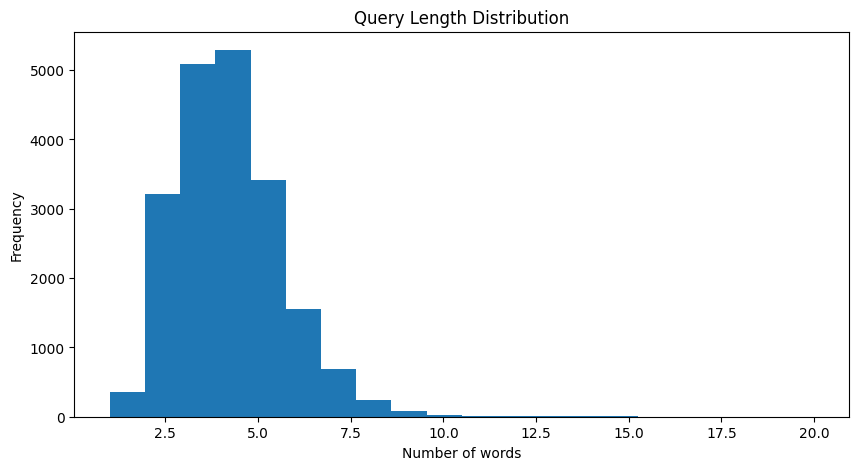

In [6]:
# распределение длины запросов

plt.figure(figsize=(10, 5))

plt.hist(df["word_count"],
    bins=20
)

plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.title("Query Length Distribution")

plt.show()

Запросы короткие: медиана 25 символов и 4 слова. Это принципиально для выбора
подхода — контекста мало, и модели, рассчитанные на предложения, здесь работают
хуже, чем кажется.


In [7]:
# Tokenization

TOKEN_PATTERN = re.compile(r"[a-zA-Zа-яА-Я0-9]+")


def tokenize(text: str) -> list[str]:
    return TOKEN_PATTERN.findall(text)


df["tokens"] = df["query_norm"].apply(tokenize)

df[["query_norm", "tokens"]].head()

,query_norm,tokens
0,гетры y2k черные широкие,"[гетры, y2k, черные, широкие]"
1,шторы в спальню 100*210,"[шторы, в, спальню, 100, 210]"
2,big bcaa,"[big, bcaa]"
3,щетки на болгарку диолд,"[щетки, на, болгарку, диолд]"
4,цинк и медь хелат,"[цинк, и, медь, хелат]"


In [8]:
# самые популярные токены

all_tokens = []

for tokens in df["tokens"]:
    all_tokens.extend(tokens)

token_counter = Counter(all_tokens)

top_tokens = pd.DataFrame(token_counter.most_common(50),
    columns=["token", "count"]
)

top_tokens.head(30)

,token,count
0,для,5977
1,на,1844
2,с,1825
3,в,718
4,5,339
5,набор,317
6,и,316
7,см,316
8,2,293
9,1,288


In [9]:
# самые популярные пары токенов

bigrams = []

for tokens in df["tokens"]:
    for i in range(len(tokens) - 1):
        bigrams.append((tokens[i], tokens[i + 1])
        )

bigram_counter = Counter(bigrams)

top_bigrams = bigram_counter.most_common(30)

top_bigrams_df = pd.DataFrame(top_bigrams,
    columns=["bigram", "count"]
)

top_bigrams_df

,bigram,count
0,"(для, новорожденных)",266
1,"(для, девочки)",254
2,"(для, мальчика)",182
3,"(для, волос)",104
4,"(чехол, на)",102
5,"(для, дома)",95
6,"(для, обуви)",83
7,"(для, кухни)",77
8,"(на, кухню)",69
9,"(для, хранения)",64


Частые биграммы показывают, какие атрибуты вообще встречаются в запросах связками — «для новорожденных», «для девочки», «чехол на».


In [10]:
# самые популярные числа

NUMBER_PATTERN = re.compile(r"\d+")

numbers = []

for query in df["query_norm"]:

    found_numbers = NUMBER_PATTERN.findall(query)

    for value in found_numbers:
        try:
            numbers.append(int(value))
        except ValueError:
            continue

number_counter = Counter(numbers)

top_numbers = pd.DataFrame(number_counter.most_common(30),
    columns=["number", "count"]
)

top_numbers

,number,count
0,5,414
1,2,406
2,1,361
3,3,350
4,4,330
5,6,186
6,200,186
7,10,171
8,8,147
9,12,136


Числа в запросах несут разный смысл: размер обуви, объём памяти, диагональ,
модель, год. Понять, что именно, можно только по соседним словам — если рядом
«размер», это размер; если «дюймов», это диагональ. Голое число без контекста
интерпретировать нельзя, и это определяет логику извлечения размера дальше.


In [11]:
# английские и русские буквы в запросе

def has_mixed_alphabet(text: str) -> bool:
    has_latin = bool(re.search(r"[a-z]", text))
    has_cyr = bool(re.search(r"[а-я]", text))

    return has_latin and has_cyr


df["mixed_language"] = df["query_norm"].apply(has_mixed_alphabet
)

mixed_ratio = df["mixed_language"].mean()

print(f"Mixed language ratio: {mixed_ratio:.4f}")

mixed_examples = (df[df["mixed_language"]]["query_norm"]
    .head(20)
    .tolist()
)

mixed_examples

Mixed language ratio: 0.1641

['гетры y2k черные широкие',
 'иглы 30g 12 мм',
 'шторы miamoza',
 'мешок для стирки обуви nik',
 'чернила для принтера hp deskjet 2130',
 'menu_mined_131579 мыльные пузыри',
 'volvo 940 (944) 2.4 turbo diesel седан дизель 109 1990-1994 d 24 t',
 'purina pro plan для стерилизованных кошек 1.5 кг',
 'infinix note 50 про смартфон',
 'брелок сигнализации starline а 63',
 'коврик hyundai на панель',
 'роутер с сим картой tp-link',
 'toyota rav 4 ii (_a2_) 1.8 (zca25_, zca26_) suv бензин 129 2000-2005 1zz-fe',
 'chery tiggo 7 pro max автомобиль',
 'нож для удаления сорняков skrab',
 'modulen смесь',
 'игры на playstation 4 диск на русском на двоих',
 'lk9 pro часы',
 'invictus мужские',
 'bravat душевая система']

In [12]:
# Most frequent queries

top_queries = (df["query_norm"]
    .value_counts()
    .head(5)
)

top_queries

,count
query_norm,
серьги 20 мм,1
подвеска дерево золото,1
ксерокс принтер сканер цветной,1
стол кухонный 130 60,1
acer aspire switch 10 sw5 012p,1


Все запросы в выборке уникальны — частотность запросов посмотреть не получится.


In [13]:
# Поиск бессмысленных запросов

def is_noisy_query(text: str) -> bool:

    if len(text) <= 2:
        return True

    if re.fullmatch(r"\d+", text):
        return True

    return False


df["is_noisy"] = df["query_norm"].apply(is_noisy_query
)

noisy_examples = (df[df["is_noisy"]]["query_norm"]
    .head(20)
    .tolist()
)

noisy_examples

['664', 'gd', 'wi', 'rx', '067', '2450']

Шести запросам осмысленной интерпретации нет: `rx` (может быть и автомобиль,
и видеокарта), `wi` (недописанное wi-fi), голые числа. На практике поиск по ним
что-то находит — `2450` это батарейки CR2450, — но словарному подходу здесь
зацепиться не за что.


In [14]:
# Создается "словарь" из 5000 самых частых слов и словосочетаний. Каждый запрос превращается в вектор (массив из 5000 чисел)
vectorizer = TfidfVectorizer(max_features=5000,
    min_df=2,
    ngram_range=(1, 2)
)

X_tfidf = vectorizer.fit_transform(df["query_norm"]
)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")

TF-IDF matrix shape: (20000, 5000)

### Кластеризация как проверка гипотезы

Прежде чем писать словари, проверяю, не разбиваются ли запросы на смысловые
группы сами по себе. Если бы TF-IDF + KMeans давали чистые кластеры, можно было
бы строить решение на них.


In [15]:
from sklearn.cluster import KMeans

N_CLUSTERS = 25
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_tfidf)

feature_names = np.array(vectorizer.get_feature_names_out())

cluster_summaries = []
for cl in range(N_CLUSTERS):
    mask = (df["cluster"] == cl).values
    size = mask.sum()
    center = kmeans.cluster_centers_[cl]
    top_idx = center.argsort()[::-1][:8]
    top_terms = ", ".join(feature_names[top_idx])
    cluster_summaries.append({"cluster": cl, "size": size, "top_terms": top_terms})

cluster_summary_df = pd.DataFrame(cluster_summaries).sort_values("size", ascending=False)
cluster_summary_df

,cluster,size,top_terms
7,7,17766,"для, на, набор, см, женские, детский, от, мм"
6,6,259,"новорожденных, для новорожденных, для, боди, новорожденных девочек, девочек, боди для, новорожденных мальчиков"
4,4,247,"девочки, для девочки, для, шапка, чешки, чешки для, костюм, костюм для"
17,17,221,"чехол, чехол на, чехол для, на, для, iphone, на iphone, pro"
13,13,210,"костюм, спортивный, женский, костюм для, спортивный костюм, костюм женский, мужской, медицинский"
5,5,193,"без, без сахара, сахара, для, сверления, без сверления, без запаха, запаха"
14,14,162,"серебро, серьги, 925, серебро 925, кольцо, sokolov, серьги серебро, золотые"
22,22,151,"для, на, дома через, для ящиков, дневник, дневник школьный, днем, днем рождения"
15,15,111,"сумка, сумка для, для, сумка женская, женская, плечо, спортивная, ноутбука"
21,21,100,"белый, стол, белый цвета, для, комод белый, цвета, стеллаж, комод"


In [16]:
# Пара небольших кластеров для проверки, что кластеризация действительно
# выделяет содержательные группы (а не только доминирующий "мусорный" кластер)
for cl in cluster_summary_df["cluster"].tolist()[1:4]:
    print(f"--- cluster {cl}: {cluster_summary_df.loc[cluster_summary_df.cluster==cl, 'top_terms'].values[0]} ---")
    print(df.loc[df["cluster"] == cl, "query_norm"].head(6).tolist())
    print()

--- cluster 6: новорожденных, для новорожденных, для, боди, новорожденных девочек, девочек, боди для, новорожденных мальчиков ---
['шапочки весенняя на выписку для новорожденных', 'белье для новорожденных на выписку', 'шапка для новорожденных зима мальчик флис', 'боди со звездами для новорожденных', 'костюм на выписку для новорожденных лето', 'черный боди с юбкой для новорожденных']

--- cluster 4: девочки, для девочки, для, шапка, чешки, чешки для, костюм, костюм для ---
['майка для девочки 90', 'чешки для девочки в садик 26', 'джоггеры вельветовые для девочки утепленные', 'набор носков для девочки синие', 'настольная лампа для девочки', 'рюкзак для девочки 1-4 класс']

--- cluster 17: чехол, чехол на, чехол для, на, для, iphone, на iphone, pro ---
['чехол для домры малой', 'чехол на редми нот 11 про прозрачный', 'чехол на iphone 15 pro max лило и стич', 'чехол на vivo y27s прозрачный', 'чехол на iphone 14 plus the north face', 'чехол на airpods 4 зеленый']

Не разбиваются: один кластер забирает около 90% запросов, остальные 24 —
маленькие, но чистые ниши. Для запросов из 3-5 слов пересечение словаря между
разными категориями минимально, и центроидам не за что зацепиться.

Вывод для решения: кластеризация здесь годится как разведочный инструмент
(быстро находит нишевые группы), но не как способ покрыть датасет. Нужны явные
словари терминов.


### Что даёт разведочный анализ

- Запросы короткие и плотные по смыслу, контекста мало.
- Числа несут смысл только вместе с соседними словами.
- 16% запросов смешивают кириллицу и латиницу — нужен транслит в словарях.
- Интерпретация атрибута зависит от категории: «42» при категории «кроссовки» —
  размер, при категории «телевизор» — скорее диагональ.


## Часть 2. Rule-based экстрактор

Извлекаю пять атрибутов — бренд, категорию, цвет, пол/возрастную группу, размер —
плюс отдельно числа с единицей измерения (см, кг, дюймы), потому что в запросах
маркетплейса это самостоятельный частый тип атрибута.

Архитектура из трёх слоёв, без обучаемой модели поверх:

1. Словари канонических форм, набранные по частотному анализу токенов из части 1.
2. Regex для чисел с единицами и для контекстного определения размера.
3. Эвристики для неоднозначных случаев.

Код вынесен в модули `src/dictionaries.py` и `src/extractor.py` — там же
подробные обоснования каждого решения в докстрингах.


In [17]:
from src.dictionaries import BRANDS, CATEGORIES, COLORS, GENDER, UNITS
from src.extractor import extract_all, extract_brand, extract_category, extract_color, extract_gender

print(f"Брендов: {len(BRANDS)} (словоформ: {sum(len(v) for v in BRANDS.values())})")
print(f"Категорий: {len(CATEGORIES)}")
print(f"Цветов: {len(COLORS)}")
print(f"Групп пол/возраст: {len(GENDER)}")
print(f"Единиц измерения: {len(UNITS)}")

Брендов: 246 (словоформ: 510)
Категорий: 108
Цветов: 35
Групп пол/возраст: 4
Единиц измерения: 14

### Два решения, которые определили качество

**Сопоставление по границе слова, а не по подстроке.** Профилирование датасета
показало, что стем-подход даёт систематические ложные срабатывания: префикс
«сер» от цвета «серый» ловит «серьги» и «миксер», «бел» ловит «мебели», «син»
ловит «бусины» и «синтезатор». Поэтому все совпадения ищутся по границе целого
слова, а многословные формы («hugo boss», «для новорожденных») — как фраза
целиком. Внутри словаря формы отсортированы от длинных к коротким, иначе
короткое совпадение перехватывает длинное.

**Голое число не считается размером без контекста.** Приоритет такой: явный
контекст («размер 42») важнее буквенного размера (S/M/L), который важнее голого
числа. Голое число принимается за размер только если категория запроса
относится к одежде или обуви, и отдельно для взрослой сетки (38-62) и детской
обувной (16-37).


In [18]:
test_queries = [
    "nike кроссовки 42 размер мужские черные",
    "iphone 13 черный 128gb",
    "красная футболка xl",
    "samsung телевизор 55 дюймов",
    "шорты диор мужские хлопок",
    "purina pro plan для кошек 1.5 кг",
    "щетки на болгарку диолд",
    "яблоко телефон 13",
]

for q in test_queries:
    print(f"{q!r:45s} -> {extract_all(q)}")

'nike кроссовки 42 размер мужские черные'     -> {'brand': 'nike', 'category': 'кроссовки', 'color': 'черный', 'gender': 'мужской', 'size': '42', 'values_with_unit': None}
'iphone 13 черный 128gb'                      -> {'brand': 'iphone', 'category': None, 'color': 'черный', 'gender': None, 'size': None, 'values_with_unit': [('128', 'гб')]}
'красная футболка xl'                         -> {'brand': None, 'category': 'футболка', 'color': 'красный', 'gender': None, 'size': 'XL', 'values_with_unit': None}
'samsung телевизор 55 дюймов'                 -> {'brand': 'samsung', 'category': 'телевизор', 'color': None, 'gender': None, 'size': None, 'values_with_unit': [('55', 'дюйм')]}
'шорты диор мужские хлопок'                   -> {'brand': 'dior', 'category': 'шорты', 'color': None, 'gender': 'мужской', 'size': None, 'values_with_unit': None}
'purina pro plan для кошек 1.5 кг'            -> {'brand': 'purina', 'category': None, 'color': None, 'gender': None, 'size': None, 'values_with_uni

Последний случай отрабатывает не так, как хотелось бы: «яблоко телефон 13» не
даёт `brand=apple`. Бытовые синонимы вроде «яблоко» → Apple потребовали бы
отдельного слоя семантических правил — список таких синонимов не ограничен и
специфичен для домена. Осознанно оставляю за рамками словарного решения.


### Применение ко всему датасету


In [19]:
extraction = pd.json_normalize(df["query_norm"].apply(extract_all))
df = pd.concat([df.reset_index(drop=True), extraction.reset_index(drop=True)], axis=1)

df[["query_norm", "brand", "category", "color", "gender", "size", "values_with_unit"]].sample(15, random_state=1)

,query_norm,brand,category,color,gender,size,values_with_unit
11456,подставка для игрового руля,None,None,None,None,None,None
16528,ural patriot 15,None,None,None,None,None,None
3253,оружие из бумаги,None,None,None,None,None,None
18614,футболка мотолэнд 250,None,футболка,None,None,None,None
1544,детские сережки серебро для девочки,None,серьги,серебряный,детский,None,None
12568,постельное белье детское 150 110,None,постельное белье,None,детский,None,None
15497,демиан,None,None,None,None,None,None
13987,тюль ширина 200,None,тюль,None,None,None,None
9598,дисплей для samsung galaxy a30,samsung,None,None,None,None,None
6668,ремкомплект карбюратора штиль fs55,stihl,None,None,None,None,None


In [20]:
ATTRIBUTE_COLUMNS = ["brand", "category", "color", "gender", "size", "values_with_unit"]

coverage = {col: df[col].notna().mean() for col in ATTRIBUTE_COLUMNS}
coverage_df = pd.DataFrame(sorted(coverage.items(), key=lambda x: -x[1]),
    columns=["attribute", "coverage"],
)
print(coverage_df.to_string(index=False))

any_core_attr = df[["brand", "category", "color", "gender", "size"]].notna().any(axis=1)
print(f"\nЗапросов хотя бы с одним извлечённым атрибутом: {any_core_attr.mean():.1%}")

       attribute  coverage
        category   0.31280
          gender   0.12080
           brand   0.07980
           color   0.07500
values_with_unit   0.06675
            size   0.01070

Запросов хотя бы с одним извлечённым атрибутом: 45.6%

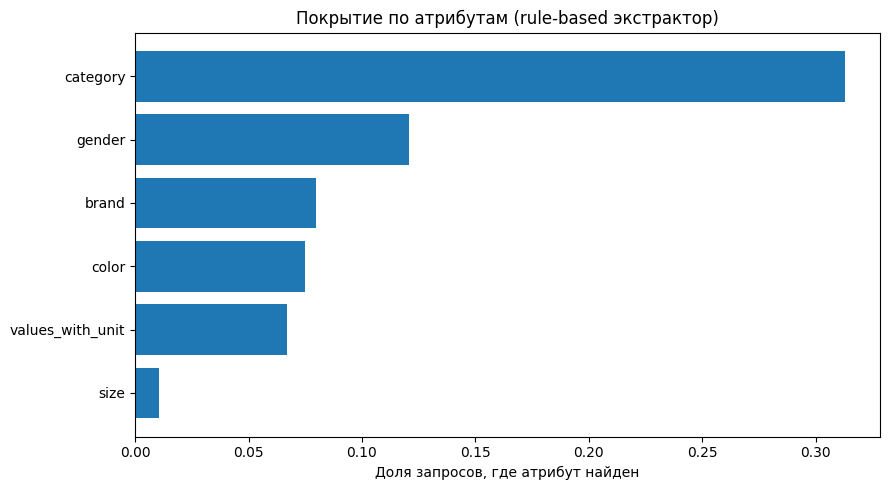

In [21]:
plt.figure(figsize=(9, 5))
plt.barh(coverage_df["attribute"], coverage_df["coverage"])
plt.xlabel("Доля запросов, где атрибут найден")
plt.title("Покрытие по атрибутам (rule-based экстрактор)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

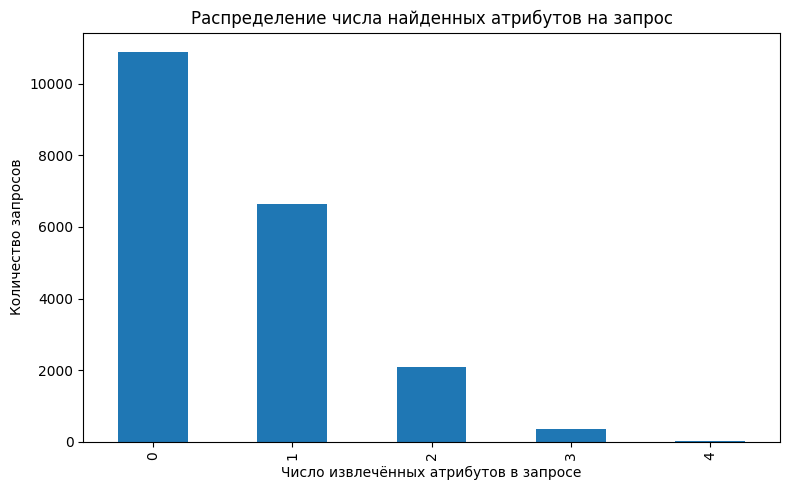

,count
0,10885
1,6647
2,2090
3,357
4,21


In [22]:
n_attrs_found = df[["brand", "category", "color", "gender", "size"]].notna().sum(axis=1)

plt.figure(figsize=(8, 5))
n_attrs_found.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Число извлечённых атрибутов в запросе")
plt.ylabel("Количество запросов")
plt.title("Распределение числа найденных атрибутов на запрос")
plt.tight_layout()
plt.show()

n_attrs_found.value_counts().sort_index()

Категория извлекается чаще всего (31%) — она обычно названа в запросе явным
существительным. Размер реже всего (1%), и это осознанный компромисс: он
извлекается только там, где контекст делает извлечение однозначным. Молчание
безопаснее ошибочного значения для того, кто эти атрибуты потом использует.


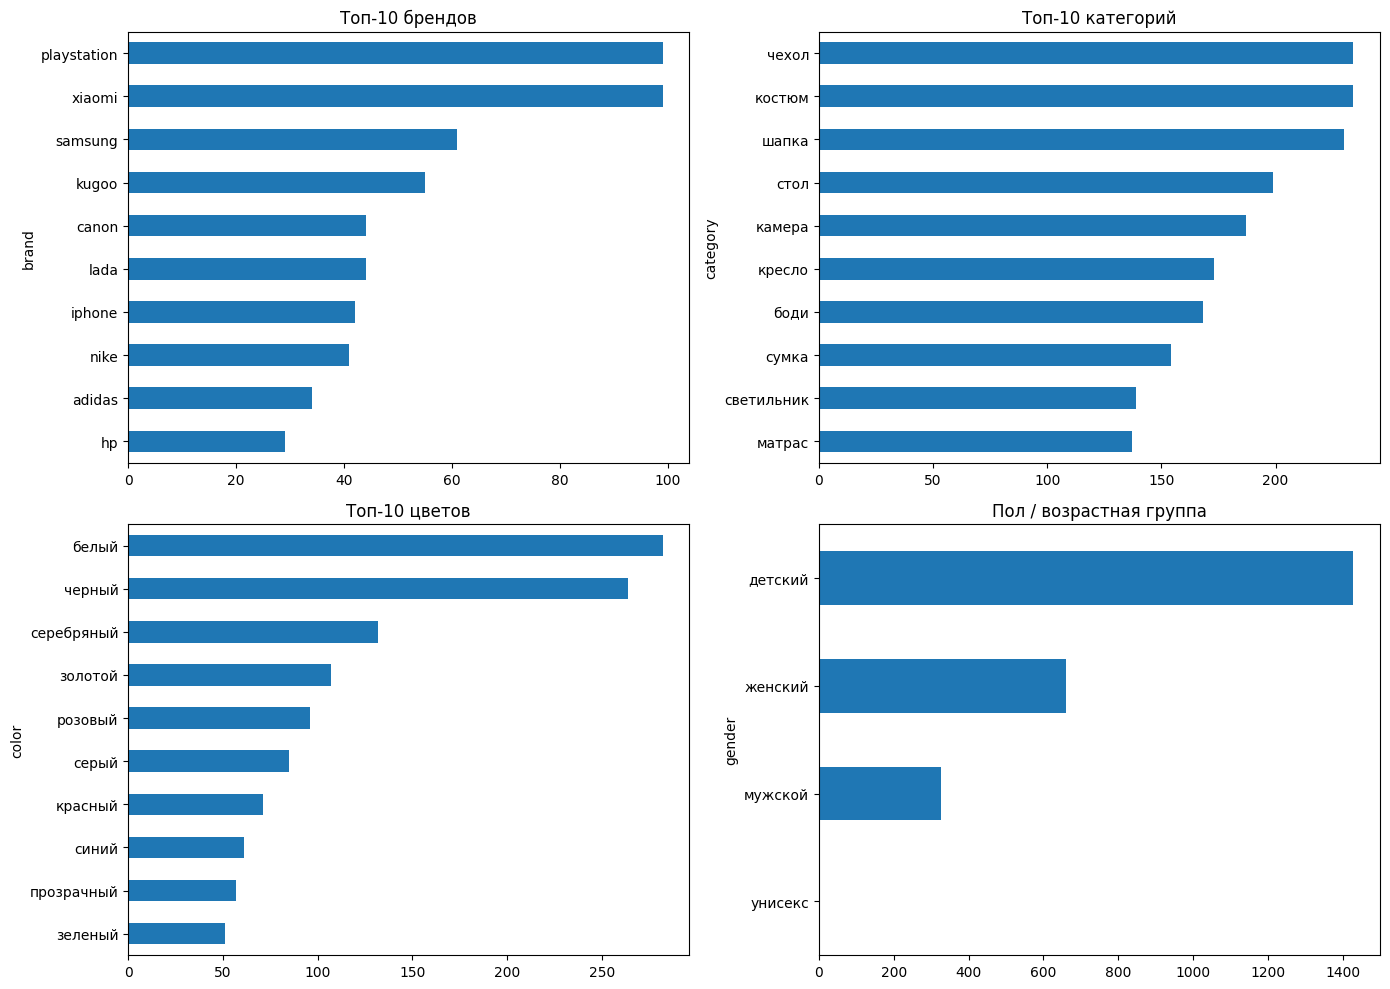

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["brand"].value_counts().head(10).plot(kind="barh", ax=axes[0, 0], title="Топ-10 брендов")
axes[0, 0].invert_yaxis()

df["category"].value_counts().head(10).plot(kind="barh", ax=axes[0, 1], title="Топ-10 категорий")
axes[0, 1].invert_yaxis()

df["color"].value_counts().head(10).plot(kind="barh", ax=axes[1, 0], title="Топ-10 цветов")
axes[1, 0].invert_yaxis()

df["gender"].value_counts().plot(kind="barh", ax=axes[1, 1], title="Пол / возрастная группа")
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## Часть 3. Валидация

Готовой разметки нет, поэтому честный precision/recall посчитать не на чем.
Вместо того чтобы приводить цифры на глаз, разметил вручную 150 случайных
запросов по всем пяти атрибутам и считаю метрики против них.

Что важно держать в голове: 150 примеров хватает, чтобы оценить порядок
качества и найти классы ошибок, но не хватает для точной оценки. Размер
встречается в выборке 5 раз — доверять конкретному проценту recall по нему
нельзя, значим только сам факт, что он заметно ниже остальных. Поэтому рядом
с точечными оценками привожу доверительные интервалы.


In [24]:
from data.ground_truth_attrs import GROUND_TRUTH
from src.metrics import score_extraction, metrics_table, wilson_interval
from src.bio import ATTRS

validation_sample = df.sample(150, random_state=100).reset_index(drop=True)
queries = validation_sample["query_norm"].tolist()

predictions = [extract_all(q) for q in queries]
ground_truth = [GROUND_TRUTH[i] for i in range(len(queries))]

counts, errors = score_extraction(queries, predictions, ground_truth)
report = metrics_table(counts, ground_truth)

report["precision_ci"] = [
    "[{:.2f}, {:.2f}]".format(*wilson_interval(counts[a]["tp"], counts[a]["tp"] + counts[a]["fp"]))
    for a in ATTRS
]
report["recall_ci"] = [
    "[{:.2f}, {:.2f}]".format(*wilson_interval(counts[a]["tp"], counts[a]["tp"] + counts[a]["fn"]))
    for a in ATTRS
]

print(report.round(3).to_string(index=False))

attribute  precision  recall    f1  support precision_ci    recall_ci
    brand      1.000   1.000 1.000       14 [0.78, 1.00] [0.78, 1.00]
 category      0.892   0.967 0.928       60 [0.79, 0.95] [0.89, 0.99]
    color      1.000   1.000 1.000       15 [0.80, 1.00] [0.80, 1.00]
   gender      1.000   1.000 1.000       17 [0.82, 1.00] [0.82, 1.00]
     size      1.000   0.400 0.571        5 [0.34, 1.00] [0.12, 0.77]

Как читать эти цифры. brand, color и gender вышли на 100% на этой конкретной
выборке — это не «задача решена», а «на 150 запросах экстрактор не ошибся ни
разу». Доверительный интервал показывает, насколько это ещё ничего не гарантирует.
Категория — основной по покрытию атрибут — держит 89% precision при 97% recall.
Размер — самый слабый и по покрытию, и по recall, что ожидаемо: это самый
неоднозначный атрибут в данных.


In [25]:
errors.head(20)

,query,attribute,type,gt,pred
0,батарейки варта большие,category,FP,None,аккумулятор
1,батарейки варта большие,size,FN,большой,None
2,матрас на кровать 120х190,category,WRONG,кровать,матрас
3,колонки мачете,category,FP,None,колонка
4,краска для принтера canon g3411,category,FP,None,принтер
5,большие машины на аккумуляторе,size,FN,большой,None
6,боди 98,size,FN,98,None
7,аккумулятор для пылесоса dyson sv11,category,WRONG,пылесос,аккумулятор
8,суппорт для стиральной машины indesit,category,FP,None,стиральная машина
9,гель мыло для лап собак,category,FP,None,гель


## Часть 4. Разбор ошибок


### Запросы, где не найдено ничего


In [26]:
n_attrs = df[["brand", "category", "color", "gender", "size"]].notna().sum(axis=1)
zero_attr = df[n_attrs == 0]
print(f"{len(zero_attr)} запросов ({len(zero_attr) / len(df):.1%}) не дали ни одного атрибута")
zero_attr["query_norm"].sample(20, random_state=5).tolist()

10885 запросов (54.4%) не дали ни одного атрибута

['краска для мебели tinturia',
 'грабли телескопические',
 'рок гитара взрослая',
 'фотообои в японском стиле',
 'тряпка для очков 1 шт',
 'сухарь пазовый',
 'конфеты эли с молочной начинкой',
 'audi tt (8n3) 1.8 t купе бензин 150 2002-2006 aum',
 'шевроны мво',
 'глушилка 24 в',
 'kx mb1500 картридж',
 'подклейка обоев',
 'диодные светильники для гаража',
 'ledger nano s plus',
 'протеин universal',
 'крыло заднее иж',
 'дверь жалюзийная деревянная 394',
 'бутылка для курения',
 'бамбуковые палочки для бани',
 'шторки блэкаут для дачи']

Это не столько провалы экстрактора, сколько честный длинный хвост каталога:

- автозапчасти по каталожному коду («audi tt (8n3) 1.8 t купе бензин 150
  2002-2006 aum») — специфичный формат вне общих словарей;
- крепёж, расходники, рукоделие («сухарь пазовый», «тряпка для очков») — ни
  известного бренда, ни категории из словаря;
- узкая электроника по модельным номерам («kx mb1500 картридж», «ledger nano s
  plus»).

Расширение покрытия здесь — вопрос объёма работы над словарями под конкретные
вертикали, а не архитектурная проблема.


### Конкуренция категорий внутри запроса


In [27]:
# однословная категория "перехватывает" более специфичную --
# запрос с двумя категориями, экстрактор берёт первую по позиции
print(extract_all("аккумулятор для пылесоса dyson sv11"))
print(extract_all("матрас на кровать 120х190"))

{'brand': 'dyson', 'category': 'аккумулятор', 'color': None, 'gender': None, 'size': None, 'values_with_unit': None}
{'brand': None, 'category': 'матрас', 'color': None, 'gender': None, 'size': None, 'values_with_unit': None}

Когда запрос упоминает две категории («аккумулятор для пылесоса» — запчасть
для одной категории, названная в терминах другой), экстрактор берёт первую по
позиции. Правило простое и объяснимое, но не всегда верное. Точнее было бы
понимать синтаксическую роль слова — то есть шаг в сторону последовательной
разметки.


### Полисемия


In [28]:
# полисемия: одно и то же слово - разные сущности в разном контексте
print(extract_all("планер на рабочий стол"))       # "стол" тут не мебель, а "desktop"
print(extract_all("колонки мачете"))                 # "мачете" тут не оружие, а название/бренд игры

{'brand': None, 'category': 'стол', 'color': None, 'gender': None, 'size': None, 'values_with_unit': None}
{'brand': None, 'category': 'колонка', 'color': None, 'gender': None, 'size': None, 'values_with_unit': None}

«Стол» в «планер на рабочий стол» — не мебель. «Мачете» в «колонки мачете» —
не оружие. Словарь не различает значения одного слова в разном контексте.
Точечные исключения добавить можно, но каждое находится только ручным
просмотром; системного решения без контекстной модели нет.


### Рост против размера в детской одежде


In [29]:
# детская обувная сетка размеров пересекается с шумом (количество, возраст)
print(extract_all("стельки для кроссовок детские 24"))  # верно: размер найден
print(extract_all("носки для малыша с бантиком"))         # верно: размер не найден, чисел нет
print(extract_all("майка для девочки 90"))                 # "90" -- это рост в см, не размер по сетке

{'brand': None, 'category': 'кроссовки', 'color': None, 'gender': 'детский', 'size': '24', 'values_with_unit': None}
{'brand': None, 'category': 'носки', 'color': None, 'gender': 'детский', 'size': None, 'values_with_unit': None}
{'brand': None, 'category': 'футболка', 'color': None, 'gender': 'детский', 'size': None, 'values_with_unit': None}

В детских товарах размер часто задаётся ростом в сантиметрах (62, 74, 86, 92),
а не номером по сетке. Диапазон пересекается с возрастом, количеством и прочим
шумом. Решение здесь сознательно консервативное: не угадывать рост без единицы
измерения. Это снижает recall, но исключает больше ложных срабатываний, чем
добавляет пропусков.


## Почему нет обучаемой модели в этой части

Изначальный план предполагал третий уровень — CRF для последовательной
BIO-разметки. Здесь его нет, и вот почему.

Обучение CRF требует размеченного датасета на порядок большего, чем
валидационная выборка: типично 500-1000 запросов с тегом на каждый токен.
Разметить это вручную в рамках тестового задания нереалистично, а разметка через
LLM — отдельный нетривиальный этап со своей валидацией.

При этом rule-based уже попадает в целевой диапазон качества по главному
атрибуту. Обучаемая модель имеет смысл как следующий шаг — для recall и для
класса ошибок с полисемией, — но не как обязательная часть решения.

Этот следующий шаг и сделан во втором ноутбуке: LLM размечает обучающие данные,
поверх обучается компактный энкодер, и всё это честно сравнивается со словарями.

## Что стоит сделать дальше со словарным слоем

По приоритету, от дешёвого к дорогому:

1. **Словари под длинный хвост** — автозапчасти, крепёж, электроника по
   модельным номерам. Самый дешёвый способ поднять recall.
2. **Лемматизация** (`pymorphy2`) перед сопоставлением. Сейчас словоформы
   перечислены явно («диван, дивана, диваны») — это работает, но не
   масштабируется. Лемматизация заодно закрывает синонимы через единую
   нормальную форму.
3. **Разрешение конкуренции категорий** — эвристика «после предлога для/на идёт
   уточнение, а не главная категория» либо простой классификатор для выбора
   главной категории среди найденных кандидатов.
4. **Больше размеченных данных.** 150 примеров хватает, чтобы найти классы
   ошибок, но не хватает, чтобы различать 87% и 91% precision.


In [30]:
output_columns = ["query_text", "query_norm", "brand", "category", "color", "gender", "size", "values_with_unit"]
df[output_columns].to_csv("../data/extracted_attributes.csv", index=False)
print(f"Сохранено {len(df)} строк")

Сохранено 20000 строк